#Data Visuali

In [24]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings


In [25]:
df=pd.read_csv("cleandata.csv")
df.head()

,Unnamed: 0,order_id,ship_mode,customer_name,segment,state,country,market,region,product_id,...,profit,shipping_cost,order_priority,year,order_month,order_day,order_year,ship_month,ship_day,ship_year
0,0,AG-2011-2040,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,...,106.14,35.46,Medium,2021,1,1,2021,1,6,2021
1,1,IN-2011-47883,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,...,36.04,9.72,Medium,2021,1,1,2021,1,8,2021
2,2,HU-2011-1220,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,...,29.64,8.17,High,2021,1,1,2021,1,5,2021
3,3,IT-2011-3647632,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,OFF-PA-10001492,...,-26.06,4.82,High,2021,1,1,2021,1,5,2021
4,4,IN-2011-47883,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,FUR-FU-10003447,...,37.77,4.70,Medium,2021,1,1,2021,1,8,2021


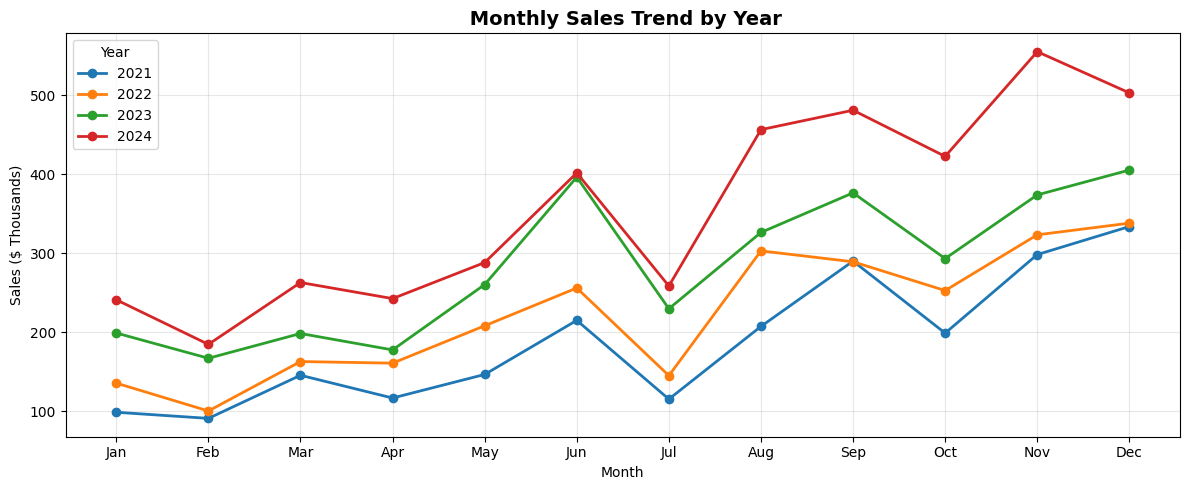

Insight: Sales consistently spike in Q4 (Oct–Dec) — holiday-driven demand across all years.


In [26]:
# Monthly Sales Trend (Line Chart) 
monthly = (
    df.groupby(["order_year", "order_month"])["sales"]
    .sum()
    .reset_index()
    .rename(columns={"order_year": "year", "order_month": "month"})
)
monthly["period"] = pd.to_datetime(monthly[["year", "month"]].assign(day=1))

fig, ax = plt.subplots(figsize=(12, 5))
for yr, grp in monthly.groupby("year"):
    ax.plot(grp["month"], grp["sales"] / 1e3, marker="o", label=str(yr), linewidth=2)
ax.set_xlabel("Month")
ax.set_ylabel("Sales ($ Thousands)")
ax.set_title(" Monthly Sales Trend by Year", fontsize=14, fontweight="bold")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
ax.legend(title="Year")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("t3_2_monthly_trend.png")
plt.show()
print("Insight: Sales consistently spike in Q4 (Oct–Dec) — holiday-driven demand across all years.")

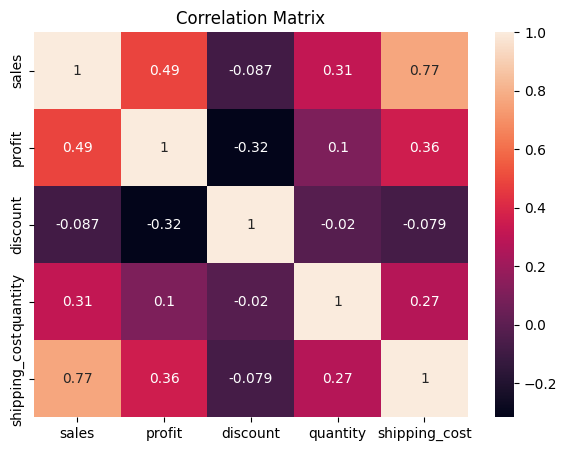


 CORRELATION INSIGHTS:

Strongest Positive Correlation: shipping_cost & sales = 0.77
 Strongest Negative Correlation: profit & discount = -0.32



In [27]:

# correlation matrix
corr = df[['sales', 'profit', 'discount', 'quantity', 'shipping_cost']].corr()

# plot heatmap
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

# PRINT INSIGHTS
print("\n CORRELATION INSIGHTS:\n")

# strongest positive correlation
max_corr = corr.unstack().sort_values(ascending=False)
max_corr = max_corr[max_corr < 1].idxmax()

# strongest negative correlation
min_corr = corr.unstack().idxmin()

print(f"Strongest Positive Correlation: {max_corr[0]} & {max_corr[1]} = {corr.loc[max_corr]:.2f}")
print(f" Strongest Negative Correlation: {min_corr[0]} & {min_corr[1]} = {corr.loc[min_corr]:.2f}\n")





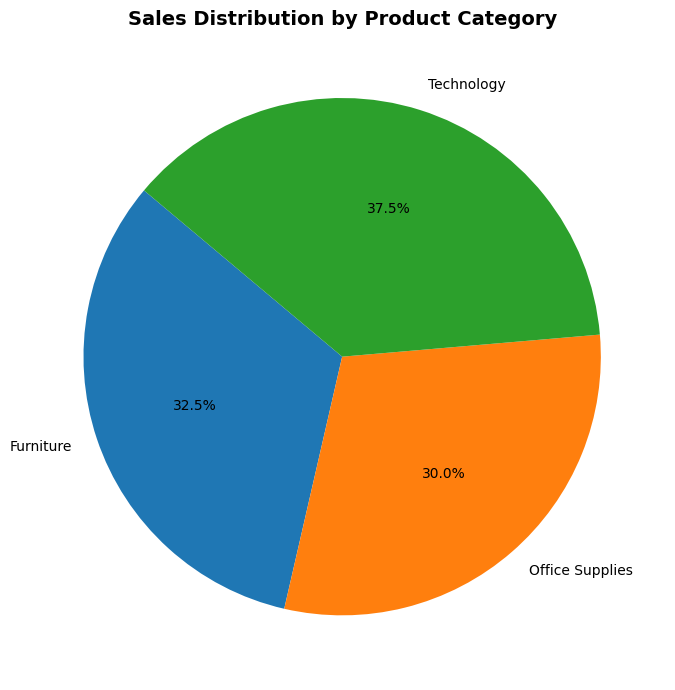

Insight: Technology contributes the largest share of total sales, followed by Furniture, while Office Supplies accounts for a smaller portion, indicating lower revenue contribution compared to other categories.


In [28]:
#Sales Distribution by Product Category
# group only sales
cat_sales = df.groupby("category")["sales"].sum()

# create pie chart
plt.figure(figsize=(7, 7))
plt.pie(
    cat_sales,
    labels=cat_sales.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Sales Distribution by Product Category", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("t3_1_category_pie.png")
plt.show()

# insight
print("Insight: Technology contributes the largest share of total sales, followed by Furniture, while Office Supplies accounts for a smaller portion, indicating lower revenue contribution compared to other categories.")

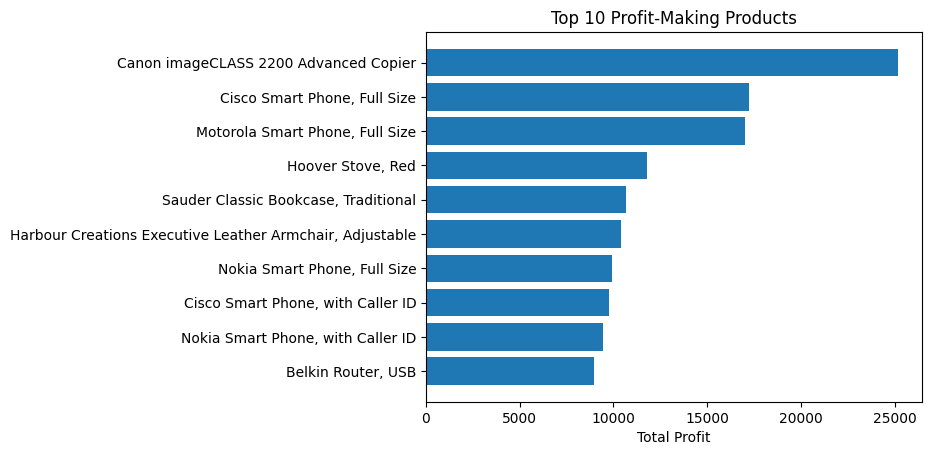

Canon imageClASS generate the highest total profit for the business.


In [29]:

# group by product and sum profit
top10_profit = df.groupby('product_name')['profit'].sum().sort_values(ascending=False).head(10)
# VISUALIZATION
plt.figure()
plt.barh(top10_profit.index, top10_profit.values)
plt.xlabel("Total Profit")
plt.title("Top 10 Profit-Making Products")
plt.gca().invert_yaxis()
plt.show()

# INSIGHTS
print("Canon imageClASS generate the highest total profit for the business.")

## Feature	engineering

In [30]:

df["profit_margin"] = (df["profit"] / df["sales"]).replace([np.inf, -np.inf], np.nan)
df["is_loss"]       = df["profit"] < 0
df["revenue_band"]  = pd.cut(
    df["sales"],
    bins=[0, 100, 500, 1000, 5000, np.inf],
    labels=["<100", "100-500", "500-1K", "1K-5K", ">5K"]
)

print("\nFeature engineering complete.")
print(df[[ "profit_margin", "is_loss", "revenue_band"]].head(3))




Feature engineering complete.
   profit_margin  is_loss revenue_band
0       0.260147    False      100-500
1       0.300333    False      100-500
2       0.449091    False         <100


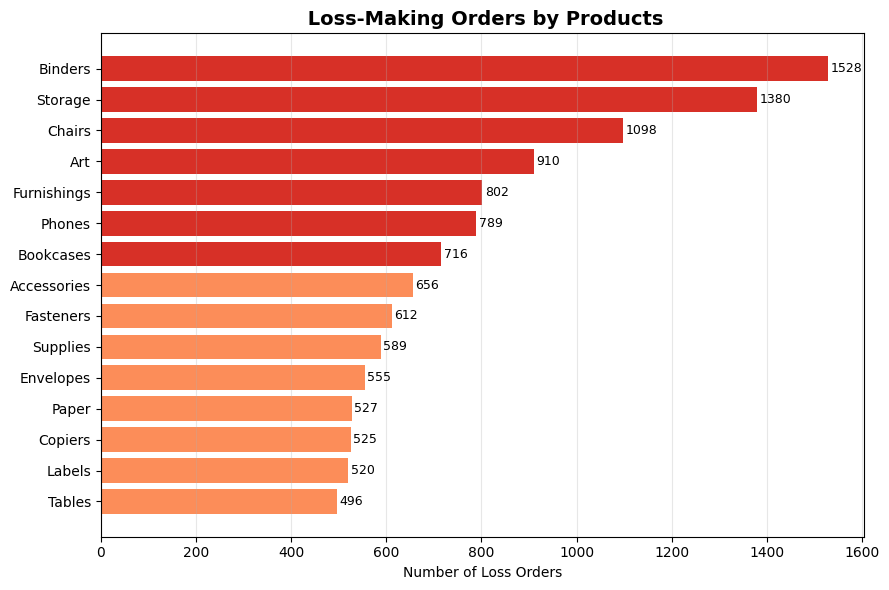

Insight: Binders, Paper, and Furnishings generate the most loss orders — driven by high discount rates.


In [31]:

# Loss Orders by Products
#  (Horizontal Bar) 
loss_by_sub = (
    df[df["is_loss"]]
    .groupby("sub_category")["order_id"]
    .count()
    .sort_values(ascending=True)
    .tail(15)
)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#d73027" if v > loss_by_sub.median() else "#fc8d59" for v in loss_by_sub]
ax.barh(loss_by_sub.index, loss_by_sub.values, color=colors)
ax.set_title(" Loss-Making Orders by Products", fontsize=14, fontweight="bold")
ax.set_xlabel("Number of Loss Orders")
ax.grid(axis="x", alpha=0.3)
for i, v in enumerate(loss_by_sub.values):
    ax.text(v + 5, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("t3_6_loss_subcat.png")
plt.show()
print("Insight: Binders, Paper, and Furnishings generate the most loss orders — driven by high discount rates.")



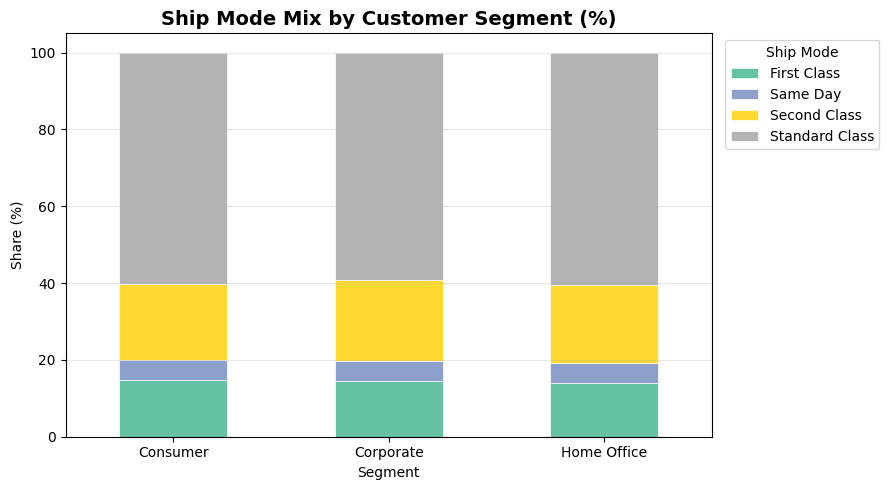

Insight: Standard Class dominates all segments (~60%). Home Office uses Same-Day shipping more than others.


In [32]:
#Sales by Segment × Ship Mode (Stacked Bar) 
seg_ship = df.groupby(["segment", "ship_mode"])["sales"].sum().unstack(fill_value=0)
seg_ship = seg_ship.div(seg_ship.sum(axis=1), axis=0) * 100  # normalize to %

fig, ax = plt.subplots(figsize=(9, 5))
seg_ship.plot(kind="bar", stacked=True, ax=ax,
              colormap="Set2", edgecolor="white", linewidth=0.5)
ax.set_title("Ship Mode Mix by Customer Segment (%)", fontsize=14, fontweight="bold")
ax.set_ylabel("Share (%)")
ax.set_xlabel("Segment")
ax.set_xticklabels(seg_ship.index, rotation=0)
ax.legend(title="Ship Mode", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("t3_7_segment_shipmode.png")
plt.show()
print("Insight: Standard Class dominates all segments (~60%). "
      "Home Office uses Same-Day shipping more than others.")



In [34]:

# ── T4-ADV 4: MULTI-LAYER VISUALIZATION ─────────────────────
# Layered view: Sales Bubble + Profit Heatmap overlay per Region × Category
# ─────────────────────────────────────────────────────────────

agg = df.groupby(["region", "category"]).agg(
    sales=("sales", "sum"),
    profit=("profit", "sum"),
    orders=("order_id", "count")
).reset_index()
agg["margin"] = agg["profit"] / agg["sales"] * 100

fig_ml = px.scatter(
    agg,
    x="category",
    y="region",
    size="sales",
    color="margin",
    hover_name="region",
    hover_data={"sales": ":,.0f", "profit": ":,.0f", "orders": True},
    color_continuous_scale="RdYlGn",
    color_continuous_midpoint=0,
    size_max=60,
    title=" Multi-Layer: Sales Volume (Bubble Size) & Profit Margin (Color) by Region × Category"
)
fig_ml.update_layout(height=650, paper_bgcolor="white",
                     coloraxis_colorbar=dict(title="Profit Margin %"))



ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'customdata': {'bdata': ('AAAAANDCB0HrUbgeBcPPQAAAAAAAuI' ... 'AAAGjDDkHsUbge/aHlQAAAAAAAuIJA'),
                             'dtype': 'f8',
                             'shape': '39, 3'},
              'hovertemplate': ('<b>%{hovertext}</b><br><br>cat' ... '%{marker.color}<extra></extra>'),
              'hovertext': array(['Africa', 'Africa', 'Africa', 'Canada', 'Canada', 'Canada', 'Caribbean',
                                  'Caribbean', 'Caribbean', 'Central', 'Central', 'Central',
                                  'Central Asia', 'Central Asia', 'Central Asia', 'EMEA', 'EMEA', 'EMEA',
                                  'East', 'East', 'East', 'North', 'North', 'North', 'North Asia',
                                  'North Asia', 'North Asia', 'Oceania', 'Oceania', 'Oceania', 'South',
                                  'South', 'South', 'Southeast Asia', 'Southeast Asia', 'Southeast Asia',
                                  'West', 'West', 'West'], dtype=object),
              'legendgroup': '',
              'marker': {'color': {'bdata': ('8LNDaYG1IEBIRZukaVolQPs5bem2YC' ... '/4WYQ3EkBLVTmEa9E3QDSUDIV7lDFA'),
                                   'dtype': 'f8'},
                         'coloraxis': 'coloraxis',
                         'size': {'bdata': ('WvgCAAASBABG6wQAYykAAFV1AAC8Zg' ... 'gEAJOuAwAUCAUAzNoDANFeAwBt2AMA'),
                                  'dtype': 'i4'},
                         'sizemode': 'area',
                         'sizeref': 288.4763888888889,
                         'symbol': 'circle'},
              'mode': 'markers',
              'name': '',
              'orientation': 'v',
              'showlegend': False,
              'type': 'scatter',
              'x': array(['Furniture', 'Office Supplies', 'Technology', 'Furniture',
                          'Office Supplies', 'Technology', 'Furniture', 'Office Supplies',
                          'Technology', 'Furniture', 'Office Supplies', 'Technology', 'Furniture',
                          'Office Supplies', 'Technology', 'Furniture', 'Office Supplies',
                          'Technology', 'Furniture', 'Office Supplies', 'Technology', 'Furniture',
                          'Office Supplies', 'Technology', 'Furniture', 'Office Supplies',
                          'Technology', 'Furniture', 'Office Supplies', 'Technology', 'Furniture',
                          'Office Supplies', 'Technology', 'Furniture', 'Office Supplies',
                          'Technology', 'Furniture', 'Office Supplies', 'Technology'],
                         dtype=object),
              'xaxis': 'x',
              'y': array(['Africa', 'Africa', 'Africa', 'Canada', 'Canada', 'Canada', 'Caribbean',
                          'Caribbean', 'Caribbean', 'Central', 'Central', 'Central',
                          'Central Asia', 'Central Asia', 'Central Asia', 'EMEA', 'EMEA', 'EMEA',
                          'East', 'East', 'East', 'North', 'North', 'North', 'North Asia',
                          'North Asia', 'North Asia', 'Oceania', 'Oceania', 'Oceania', 'South',
                          'South', 'South', 'Southeast Asia', 'Southeast Asia', 'Southeast Asia',
                          'West', 'West', 'West'], dtype=object),
              'yaxis': 'y'}],
    'layout': {'coloraxis': {'cmid': 0,
                             'colorbar': {'title': {'text': 'Profit Margin %'}},
                             'colorscale': [[0.0, 'rgb(165,0,38)'], [0.1,
                                            'rgb(215,48,39)'], [0.2,
                                            'rgb(244,109,67)'], [0.3,
                                            'rgb(253,174,97)'], [0.4,
                                            'rgb(254,224,139)'], [0.5,
                                            'rgb(255,255,191)'], [0.6,
                                            'rgb(217,239,139)'], [0.7,
                                            'rgb(166,217,106)'], [0.8,
                  